<a href="https://colab.research.google.com/github/keksenia/crowdsourcing-quality-control/blob/main/crowdsourcing_quality_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install crowd-kit pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 2.5 MB/s eta 0:00:00


In [2]:
from crowdkit.datasets import load_dataset

df, gt = load_dataset('relevance-2')
print(df.shape)
print(df.head())
print("задач:", df.task.nunique(), "| исполнителей:", df.worker.nunique())

Unpacking relevance-2.zip
(475536, 3)
  worker    task  label
0   w851  t30685      1
1  w6991  t30008      0
2  w2596  t36316      0
3  w5507  t15145      1
4  w2982  t44785      1
задач: 99319 | исполнителей: 7138


In [3]:
# 1. здесь мы смотрим на эталон
print(type(gt))
print(gt.head())
print("задач с эталоном:", gt.shape[0])

# 2. а тут приклеиваем правильный ответ к каждой проставленной метке
gt_df = gt.reset_index()
gt_df.columns = ["task", "true_label"]

merged = df.merge(gt_df, on="task", how="inner")
merged["correct"] = (merged["label"] == merged["true_label"]).astype(int)

# 3. обращаем внимание на главное число: насколько в среднем одиночная метка совпадает с эталоном
print("строк после склейки:", merged.shape[0])
print("сырая точность одиночной метки:", round(merged["correct"].mean(), 3))

<class 'pandas.core.series.Series'>
task
t30006    0
t33578    0
t22462    1
t52093    0
t26935    0
Name: true_label, dtype: int64
задач с эталоном: 10079
строк после склейки: 48268
сырая точность одиночной метки: 0.699


In [4]:
# качество каждого исполнителя на задачах с эталоном
worker_quality = (
    merged.groupby("worker")
    .agg(n_tasks=("correct", "size"), accuracy=("correct", "mean"))
    .reset_index()
)

# надёжно оценить можно только тех, у кого достаточно задач
reliable = worker_quality[worker_quality["n_tasks"] >= 10]

print("исполнителей с эталоном всего:", worker_quality.shape[0])
print("из них с >= 10 задачами:", reliable.shape[0])
print(reliable["accuracy"].describe().round(3))
print("доля 'вредных' (точность < 0.5):", round((reliable["accuracy"] < 0.5).mean(), 3))
print("\nХудшие:\n", reliable.sort_values("accuracy").head())
print("\nЛучшие:\n", reliable.sort_values("accuracy").tail())

исполнителей с эталоном всего: 7054
из них с >= 10 задачами: 1327
count    1327.000
mean        0.756
std         0.129
min         0.200
25%         0.686
50%         0.770
75%         0.846
max         1.000
Name: accuracy, dtype: float64
доля 'вредных' (точность < 0.5): 0.026

Худшие:
      worker  n_tasks  accuracy
3913  w4564       10  0.200000
5875  w6348       11  0.272727
6051  w6506       10  0.300000
4496  w5091       19  0.315789
237   w1212       12  0.333333

Лучшие:
      worker  n_tasks  accuracy
4951  w5505       12       1.0
4934  w5490       10       1.0
5056  w5600       28       1.0
7045   w991       12       1.0
7     w1003       13       1.0


In [5]:
from crowdkit.aggregation import MajorityVote, DawidSkene
from sklearn.metrics import accuracy_score

# удобно для сравнения
truth = gt_df.set_index("task")["true_label"]

# метод 1: простое большинство голосов
mv = MajorityVote().fit_predict(df)

# метод 2: учитывает надёжность исполнителей
ds = DawidSkene(n_iter=20).fit_predict(df)

# сравниваем обе агрегации с эталоном — только по задачам, где эталон есть
common = truth.index.intersection(mv.index)

acc_mv = accuracy_score(truth.loc[common], mv.loc[common])
acc_ds = accuracy_score(truth.loc[common], ds.loc[common])

print("сырая точность одиночной метки:   0.699")
print("точность Majority Vote:           ", round(acc_mv, 3))
print("точность Dawid-Skene:             ", round(acc_ds, 3))

сырая точность одиночной метки:   0.699
точность Majority Vote:            0.776
точность Dawid-Skene:              0.809


In [6]:
import numpy as np

# берём результат Dawid-Skene и сравниваем с эталоном по общим задачам
agg = ds.loc[common]
true = truth.loc[common]
is_correct = (agg.values == true.values).astype(int)

N = len(is_correct)
true_quality = is_correct.mean()   # "настоящее" качество по всем задачам с эталоном

# теперь притворимся, что проверять всё нам будет дорого — для этого берём выборку
def estimate(sample_size, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(N, size=sample_size, replace=False)
    s = is_correct[idx]
    p = s.mean()
    se = np.sqrt(p * (1 - p) / sample_size)   # стандартная ошибка
    return p, p - 1.96*se, p + 1.96*se        # оценка и доверительный интервал

print("истинное качество по всем", N, "задачам:", round(true_quality, 3), "\n")
for n in [50, 200, 1000]:
    p, lo, hi = estimate(n)
    print(f"выборка {n:>4}: оценка {p:.3f}  | 95% интервал [{lo:.3f}, {hi:.3f}]  | ширина ±{(hi-lo)/2:.3f}")

истинное качество по всем 10079 задачам: 0.809 

выборка   50: оценка 0.860  | 95% интервал [0.764, 0.956]  | ширина ±0.096
выборка  200: оценка 0.740  | 95% интервал [0.679, 0.801]  | ширина ±0.061
выборка 1000: оценка 0.795  | 95% интервал [0.770, 0.820]  | ширина ±0.025


In [7]:
# бонусное правило: кого премировать, кого учить, кого убирать
def assign_status(row):
    if row["n_tasks"] >= 10 and row["accuracy"] >= 0.85:
        return "бонус"
    elif row["accuracy"] < 0.5:
        return "из потока"
    else:
        return "на обучение"

reliable = reliable.copy()
reliable["status"] = reliable.apply(assign_status, axis=1)

summary = reliable["status"].value_counts()
print("Распределение исполнителей по статусу:\n", summary, "\n")
print("Доля на бонус:", round((reliable["status"] == "бонус").mean(), 3))
print("Средняя точность бонусных:",
      round(reliable.loc[reliable["status"] == "бонус", "accuracy"].mean(), 3))

Распределение исполнителей по статусу:
 status
на обучение    967
бонус          325
из потока       35
Name: count, dtype: int64 

Доля на бонус: 0.245
Средняя точность бонусных: 0.906


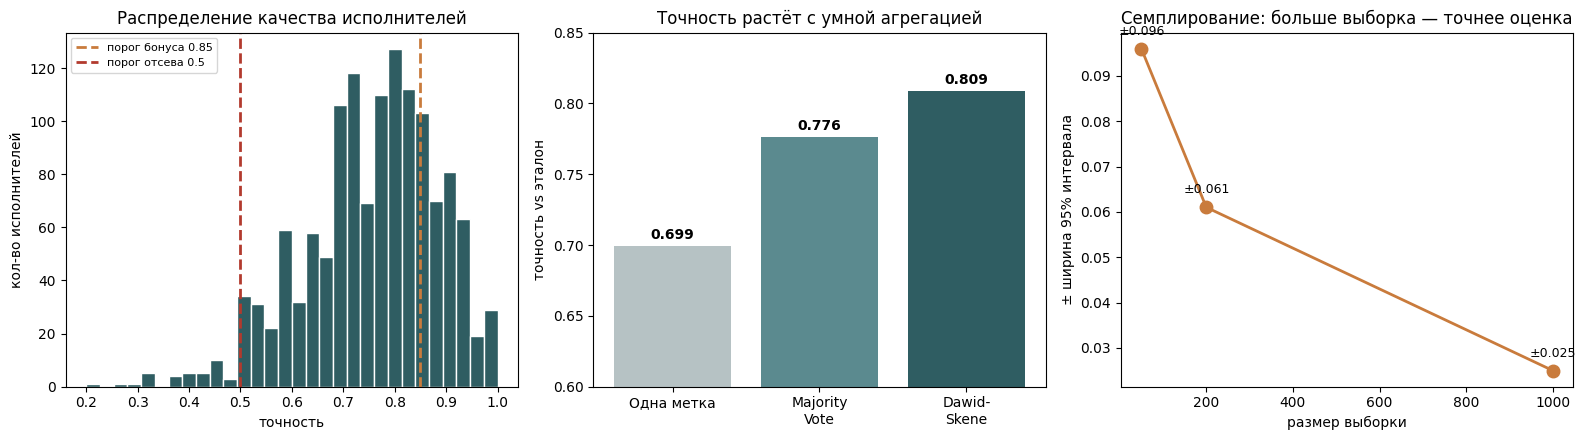

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. распределение точности исполнителей
axes[0].hist(reliable["accuracy"], bins=30, color="#2f5d62", edgecolor="white")
axes[0].axvline(0.85, color="#c97b3c", linestyle="--", linewidth=2, label="порог бонуса 0.85")
axes[0].axvline(0.5, color="#b23a2e", linestyle="--", linewidth=2, label="порог отсева 0.5")
axes[0].set_title("Распределение качества исполнителей")
axes[0].set_xlabel("точность"); axes[0].set_ylabel("кол-во исполнителей")
axes[0].legend(fontsize=8)

# 2. рост точности от метода агрегации
methods = ["Одна метка", "Majority\nVote", "Dawid-\nSkene"]
scores = [0.699, 0.776, 0.809]
bars = axes[1].bar(methods, scores, color=["#b6c2c4", "#5b8a8f", "#2f5d62"])
axes[1].set_ylim(0.6, 0.85)
axes[1].set_title("Точность растёт с умной агрегацией")
axes[1].set_ylabel("точность vs эталон")
for b, s in zip(bars, scores):
    axes[1].text(b.get_x()+b.get_width()/2, s+0.005, f"{s:.3f}", ha="center", fontweight="bold")

# 3. как сужается доверительный интервал с ростом выборки
sizes = [50, 200, 1000]
widths = [0.096, 0.061, 0.025]
axes[2].plot(sizes, widths, "o-", color="#c97b3c", linewidth=2, markersize=9)
axes[2].set_title("Семплирование: больше выборка — точнее оценка")
axes[2].set_xlabel("размер выборки"); axes[2].set_ylabel("± ширина 95% интервала")
for x, y in zip(sizes, widths):
    axes[2].annotate(f"±{y}", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("Размер df:", df.shape)
print("Колонки:", list(df.columns))
print("Уникальных меток:", sorted(df["label"].unique()))
print("\nСколько исполнителей в среднем размечают одну задачу:")
print(df.groupby("task")["worker"].count().describe().round(2))

Размер df: (475536, 3)
Колонки: ['worker', 'task', 'label']
Уникальных меток: [np.int64(0), np.int64(1)]

Сколько исполнителей в среднем размечают одну задачу:
count    99319.00
mean         4.79
std          0.69
min          1.00
25%          5.00
50%          5.00
75%          5.00
max          5.00
Name: worker, dtype: float64
